# Question 2 (10 marks)

Assume the initial position of the end-effector is p = (1, 2, 3). The goal is for the end-effector to pass through a via-point (5, 10, 12) at t = 1s and reach the goal at (10, 8, 7) by t = 5s.

1. Generate a 3D trajectory for the end-effector using three second-order polynomials, one for each dimension (planning in Cartesian space).
2. Plot the generated trajectories in the form of t-x, t-y, and t-z (one figure for each dimension).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

X-coefficients [a, b, c]: [-0.55  4.55  1.  ]
Y-coefficients [a, b, c]: [-1.7  9.7  2. ]
Z-coefficients [a, b, c]: [-2.05 11.05  3.  ]


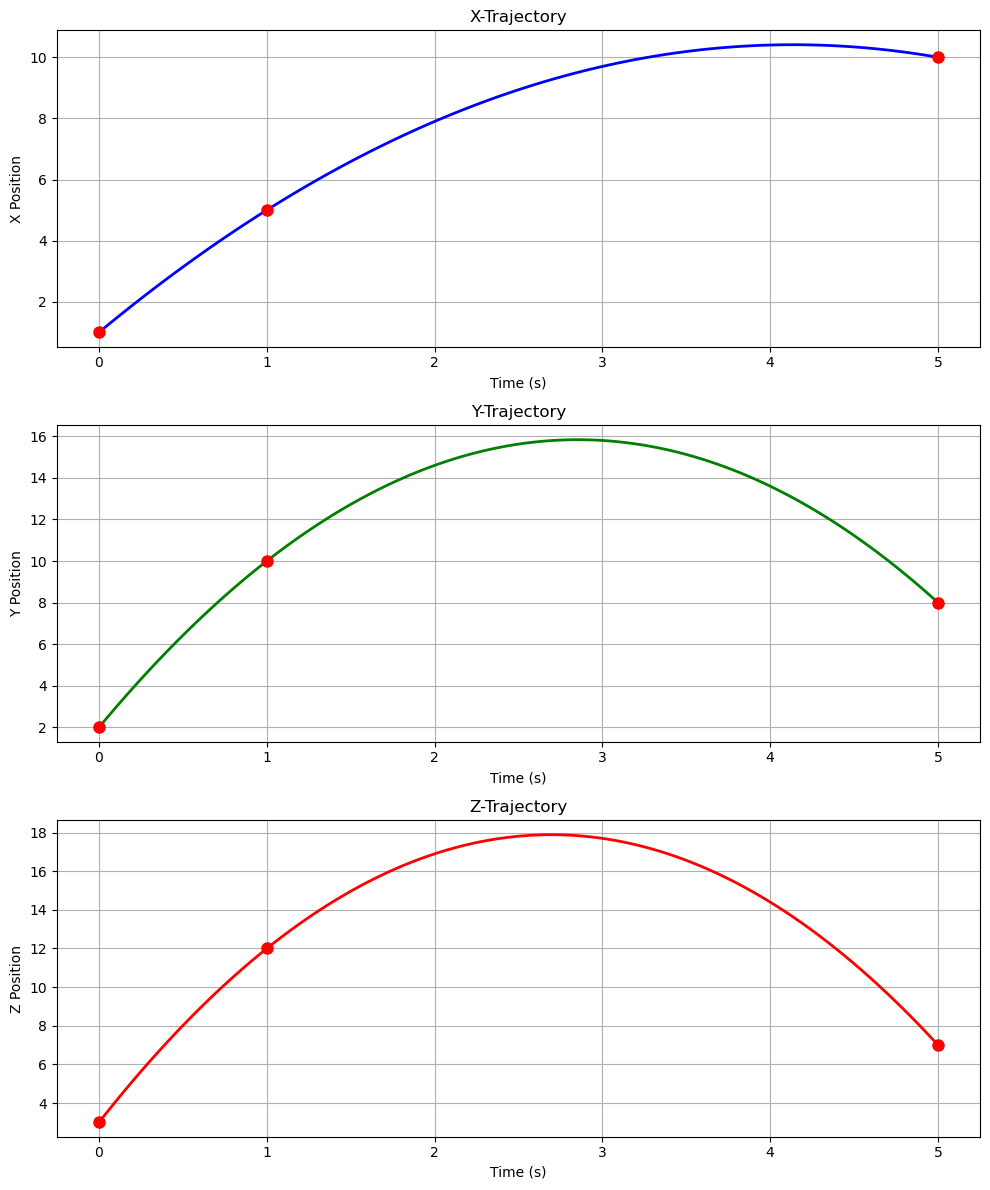

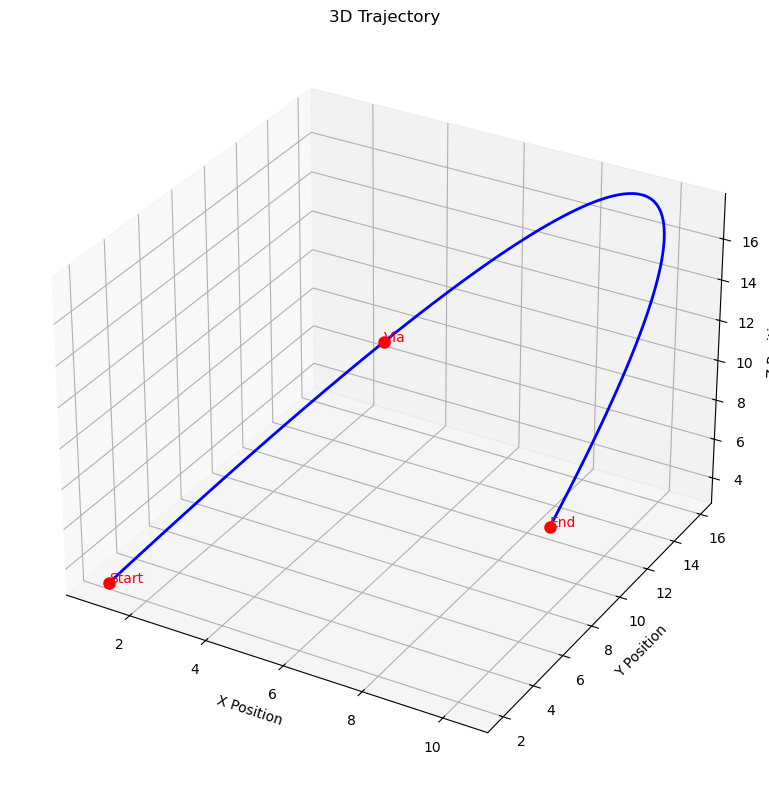

In [6]:
# Second-order polynomials trajectory
# x(t) = a_x * t^2 + b_x * t + c_x
# y(t) = a_y * t^2 + b_y * t + c_y
# z(t) = a_z * t^2 + b_z * t + c_z

# define the time and position of start point, via point and end-point
start_point, via_point, end_point = np.array([1, 2, 3]), np.array([5, 10, 12]), np.array([10, 8, 7])
points = np.array([
    start_point,
    via_point,
    end_point
])
start_time, via_time, end_time = 0.0, 1.0, 5.0

# TODO: implement your code here. When you plot your trajectories, remember to display the start-, via-, and end-point.
# Function to solve for the coefficients of the second-order polynomial
def solve_polynomial_coefficients(p0, p1, p2, t0, t1, t2):
    """
    Solves for coefficients [a, b, c] of the polynomial p(t) = a*t^2 + b*t + c
    given three points (t0,p0), (t1,p1), (t2,p2)
    """
    # Set up the system of equations
    A = np.array([
        [t0**2, t0, 1],
        [t1**2, t1, 1],
        [t2**2, t2, 1]
    ])
    b = np.array([p0, p1, p2])
    
    # Solve for coefficients [a, b, c]
    coeffs = np.linalg.solve(A, b)
    
    return coeffs

# Solve for coefficients in each dimension
x_coeffs = solve_polynomial_coefficients(
    start_point[0], via_point[0], end_point[0],
    start_time, via_time, end_time
)

y_coeffs = solve_polynomial_coefficients(
    start_point[1], via_point[1], end_point[1],
    start_time, via_time, end_time
)

z_coeffs = solve_polynomial_coefficients(
    start_point[2], via_point[2], end_point[2],
    start_time, via_time, end_time
)

print(f"X-coefficients [a, b, c]: {x_coeffs}")
print(f"Y-coefficients [a, b, c]: {y_coeffs}")
print(f"Z-coefficients [a, b, c]: {z_coeffs}")

# Function to compute trajectory points
def compute_trajectory(coeffs, t):
    """Compute position at time t using polynomial coefficients [a, b, c]"""
    a, b, c = coeffs
    return a * t**2 + b * t + c

# Generate time samples for the trajectory
t_samples = np.linspace(start_time, end_time, 100)

# Calculate trajectory points
x_traj = [compute_trajectory(x_coeffs, t) for t in t_samples]
y_traj = [compute_trajectory(y_coeffs, t) for t in t_samples]
z_traj = [compute_trajectory(z_coeffs, t) for t in t_samples]

# Plot t-x, t-y, and t-z trajectories
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# t-x plot
axs[0].plot(t_samples, x_traj, 'b-', linewidth=2)
axs[0].plot([start_time, via_time, end_time], 
           [start_point[0], via_point[0], end_point[0]], 'ro', markersize=8)
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('X Position')
axs[0].set_title('X-Trajectory')
axs[0].grid(True)

# t-y plot
axs[1].plot(t_samples, y_traj, 'g-', linewidth=2)
axs[1].plot([start_time, via_time, end_time], 
           [start_point[1], via_point[1], end_point[1]], 'ro', markersize=8)
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Y Position')
axs[1].set_title('Y-Trajectory')
axs[1].grid(True)

# t-z plot
axs[2].plot(t_samples, z_traj, 'r-', linewidth=2)
axs[2].plot([start_time, via_time, end_time], 
           [start_point[2], via_point[2], end_point[2]], 'ro', markersize=8)
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('Z Position')
axs[2].set_title('Z-Trajectory')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# Plot 3D trajectory
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_traj, y_traj, z_traj, 'b-', linewidth=2)
ax.plot([start_point[0], via_point[0], end_point[0]], 
        [start_point[1], via_point[1], end_point[1]], 
        [start_point[2], via_point[2], end_point[2]], 'ro', markersize=8)

# Label the points
ax.text(start_point[0], start_point[1], start_point[2], 'Start', color='red')
ax.text(via_point[0], via_point[1], via_point[2], 'Via', color='red')
ax.text(end_point[0], end_point[1], end_point[2], 'End', color='red')

ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.set_title('3D Trajectory')

plt.tight_layout()
plt.show()




In [7]:
# NOTE: For this question, you don't need to discuss the results in your report. You only need to the implement the trajectory generation in the above cell.
